[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/streaming-interruption.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239464-lesson-1-streaming)

# 流式处理 (Streaming)

## 回顾

在模块2中，我们学习了自定义图状态和内存的几种方法。
 
我们构建了一个具有外部内存的聊天机器人，能够维持长时间的对话。 

## 学习目标

本模块将深入探讨"人在回路中"(human-in-the-loop)技术，该技术基于内存机制，允许用户以各种方式直接与图进行交互。 

为了为"人在回路中"技术奠定基础，我们将首先学习流式处理，它提供了多种方式来可视化图在执行过程中的输出（例如，节点状态或聊天模型的token）。

### 流式处理的重要性
- **实时反馈**：用户可以实时看到AI的思考和生成过程
- **更好的用户体验**：避免长时间等待，提供即时响应
- **调试和监控**：开发者可以观察图的执行流程和状态变化
- **交互式应用**：支持更自然的对话式交互体验

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk

## 流式处理基础

LangGraph 内置了[一流的流式处理支持](https://langchain-ai.github.io/langgraph/concepts/low_level/#streaming)。

让我们设置来自模块2的聊天机器人，并展示在图执行过程中流式输出结果的各种方法。

### 流式处理的核心概念
- **状态流式传输**：实时传输图的状态变化
- **Token流式传输**：逐token传输大语言模型的生成内容
- **事件流式传输**：传输图执行过程中的各种事件
- **消息流式传输**：专门针对消息列表的流式处理 

In [ ]:
import os, getpass

def _set_env(var: str):
    """
    安全地设置环境变量
    如果环境变量不存在，则提示用户输入
    
    Args:
        var (str): 要设置的环境变量名称
    """
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置OpenAI API密钥，这是使用GPT模型所必需的
_set_env("OPENAI_API_KEY")

**重要提示**：我们使用 `RunnableConfig` 与 `call_model` 来启用逐token的流式传输。这在 [Python < 3.11 版本中是必需的](https://langchain-ai.github.io/langgraph/how-tos/streaming-tokens/)。我们包含这个配置是为了确保在Google Colab（使用Python 3.x）中也能正常运行。

### 为什么需要RunnableConfig？
- **兼容性**：确保在不同Python版本中的一致性行为
- **流式传输**：启用token级别的实时流式输出
- **配置管理**：统一管理运行时的各种配置参数 

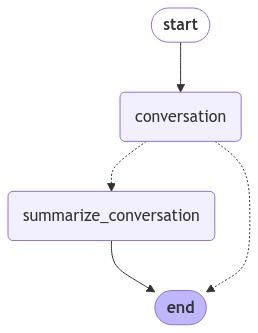

In [ ]:
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# 初始化大语言模型
# 使用GPT-4o模型，temperature=0确保输出更加确定性和一致
model = ChatOpenAI(model="gpt-4o", temperature=0) 

# 定义图的状态类
# 继承MessagesState，添加summary字段用于存储对话摘要
class State(MessagesState):
    summary: str  # 存储对话的摘要信息

def call_model(state: State, config: RunnableConfig):
    """
    调用大语言模型的核心函数
    
    这个函数负责：
    1. 检查是否存在对话摘要
    2. 如果有摘要，将其作为系统消息添加到对话中
    3. 调用LLM生成回复
    
    Args:
        state (State): 当前图的状态，包含消息列表和摘要
        config (RunnableConfig): 运行时配置，用于启用流式传输
        
    Returns:
        dict: 包含AI回复消息的字典
    """
    
    # 获取现有的对话摘要（如果存在）
    summary = state.get("summary", "")

    # 如果存在摘要，将其添加到对话中
    if summary:
        # 创建包含摘要的系统消息
        system_message = f"Summary of conversation earlier: {summary}"

        # 将摘要作为系统消息添加到消息列表的开头
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        # 如果没有摘要，直接使用原始消息
        messages = state["messages"]
    
    # 调用大语言模型生成回复
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    """
    对话摘要生成函数
    
    当对话消息过多时，此函数会：
    1. 生成对话摘要
    2. 删除除最近2条消息外的所有消息
    3. 保持对话的上下文连续性
    
    Args:
        state (State): 当前图的状态
        
    Returns:
        dict: 包含新摘要和要删除的消息的字典
    """
    
    # 获取现有的摘要（如果存在）
    summary = state.get("summary", "")

    # 根据是否存在现有摘要创建不同的提示词
    if summary:
        # 如果已有摘要，要求扩展现有摘要
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        # 如果没有摘要，创建新的摘要
        summary_message = "Create a summary of the conversation above:"

    # 将摘要提示添加到消息历史中
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # 删除除最近2条消息外的所有消息，保持对话简洁
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

def should_continue(state: State):
    """
    决定图执行流程的函数
    
    根据对话长度决定下一步操作：
    - 如果消息超过6条，则进行摘要
    - 否则结束对话
    
    Args:
        state (State): 当前图的状态
        
    Returns:
        str: 下一个要执行的节点名称或END
    """
    
    messages = state["messages"]
    
    # 如果消息超过6条，触发对话摘要
    if len(messages) > 6:
        return "summarize_conversation"
    
    # 否则结束对话
    return END

# 构建LangGraph工作流
workflow = StateGraph(State)

# 添加节点：对话节点和摘要节点
workflow.add_node("conversation", call_model)  # 对话处理节点
workflow.add_node(summarize_conversation)      # 对话摘要节点

# 设置图的连接关系
workflow.add_edge(START, "conversation")                    # 从开始到对话节点
workflow.add_conditional_edges("conversation", should_continue)  # 条件边：根据消息数量决定下一步
workflow.add_edge("summarize_conversation", END)            # 从摘要节点到结束

# 编译图并添加内存检查点
memory = MemorySaver()  # 创建内存保存器，用于持久化对话状态
graph = workflow.compile(checkpointer=memory)

# 显示图的Mermaid可视化
display(Image(graph.get_graph().draw_mermaid_png()))

### 流式传输完整状态

现在，让我们讨论[流式传输图状态](https://langchain-ai.github.io/langgraph/concepts/low_level/#streaming)的方法。

`.stream` 和 `.astream` 是用于流式返回结果的同步和异步方法。 
 
LangGraph 支持几种[不同的流式模式](https://langchain-ai.github.io/langgraph/how-tos/stream-values/)来传输[图状态](https://langchain-ai.github.io/langgraph/how-tos/stream-values/)：
 
* `values`：在每个节点被调用后流式传输图的完整状态
* `updates`：在每个节点被调用后流式传输图状态的更新部分

![values_vs_updates.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbaf892d24625a201744e5_streaming1.png)

让我们看看 `stream_mode="updates"` 模式。

由于我们使用 `updates` 模式进行流式传输，我们只能看到图中节点运行后对状态的更新。

每个 `chunk` 都是一个字典，以 `node_name` 作为键，以更新后的状态作为值。

### 流式模式对比

| 模式 | 描述 | 适用场景 | 数据量 |
|------|------|----------|--------|
| `values` | 传输完整状态 | 需要完整上下文时 | 较大 |
| `updates` | 只传输状态变化 | 关注增量变化时 | 较小 |

### 初学者提示
- **values模式**：适合需要完整状态信息的场景，如调试或状态监控
- **updates模式**：适合实时更新UI或只关心变化部分的场景
- **性能考虑**：updates模式通常更高效，因为它只传输变化的数据

In [ ]:
# 创建对话线程
# thread_id用于标识不同的对话会话，支持多用户并发
config = {"configurable": {"thread_id": "1"}}

# 开始对话并使用updates模式进行流式传输
# 这将实时显示每个节点执行后的状态更新
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='Hi Lance! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 11, 'total_tokens': 21}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_25624ae3a5', 'finish_reason': 'stop', 'logprobs': None}, id='run-6d58e31e-a278-4df6-ab0a-bb51d08ca037-0', usage_metadata={'input_tokens': 11, 'output_tokens': 10, 'total_tokens': 21})}}


现在让我们只打印状态更新，以便更清楚地看到流式传输的效果。

In [ ]:
# 开始对话并美化打印消息
# 使用pretty_print()方法可以更清晰地显示消息内容
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Hi Lance! How are you doing today?


现在，我们可以看看 `stream_mode="values"` 模式。

这是 `conversation` 节点被调用后图的`完整状态`。

### values模式的特点
- **完整状态**：包含图中所有字段的完整信息
- **历史记录**：可以看到所有历史消息和状态
- **调试友好**：便于开发者理解图的完整执行状态

In [ ]:
# 重新开始对话，使用新的线程ID
config = {"configurable": {"thread_id": "2"}}

# 使用values模式进行流式传输
# 这将显示每次节点执行后的完整状态
input_message = HumanMessage(content="hi! I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    # 遍历并美化打印所有消息
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)  # 分隔线，便于区分不同的状态更新

================================ Human Message =================================

hi! I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hi Lance! How can I assist you today?
---------------------------------------------------------------------------


### 流式传输Token

我们通常希望流式传输的不仅仅是图状态。

特别是对于聊天模型调用，流式传输生成的token是很常见的需求。

我们可以使用[`.astream_events`方法](https://langchain-ai.github.io/langgraph/how-tos/streaming-from-final-node/#stream-outputs-from-the-final-node)来实现这一点，该方法会流式返回节点内部发生的事件！

每个事件都是一个包含几个键的字典：
 
* `event`：正在发出的事件类型
* `name`：事件的名称
* `data`：与事件关联的数据
* `metadata`：包含`langgraph_node`，即发出事件的节点

让我们来看看具体实现。

### Token流式传输的优势
- **实时响应**：用户可以实时看到AI的思考过程
- **更好的用户体验**：避免长时间等待，提供即时反馈
- **调试便利**：开发者可以观察模型的生成过程
- **交互性强**：支持更自然的对话体验

In [ ]:
# 创建新的对话线程
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")

# 使用astream_events方法流式传输事件
# version="v2"指定使用第二版API，提供更好的事件结构
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # 打印事件信息：节点名称、事件类型和事件名称
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

/var/folders/l9/bpjxdmfx7lvd1fbdjn38y5dh0000gn/T/ipykernel_66136/946416104.py:3: LangChainBetaWarning: This API is in beta and may change in the future.
  async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):


Node: . Type: on_chain_start. Name: LangGraph
Node: __start__. Type: on_chain_start. Name: __start__
Node: __start__. Type: on_chain_end. Name: __start__
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: 

关键点是，图中聊天模型生成的token具有 `on_chat_model_stream` 类型。

我们可以使用 `event['metadata']['langgraph_node']` 来选择要流式传输的节点。

我们可以使用 `event['data']` 来获取每个事件的实际数据，在这种情况下是一个 `AIMessageChunk`。

### 事件类型说明
- **`on_chat_model_stream`**：聊天模型正在生成token时触发
- **`on_chain_start/end`**：链或节点开始/结束时触发
- **`on_chat_model_start`**：聊天模型开始调用时触发

### 初学者理解要点
- 每个token都会触发一个独立的事件
- 可以通过事件类型过滤我们关心的事件
- `AIMessageChunk`包含部分生成的消息内容 

In [ ]:
# 指定要流式传输的节点
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")

# 流式传输指定节点的聊天模型token
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # 只获取特定节点的聊天模型token流
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content='The', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' San', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' Francisco', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' ', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content='49', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content='ers', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' are', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' a', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' professional', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMessageChunk(content=' American', id='run-b76ec3b8-9c45-42fe-b321-4ec3a69c185c')}
{'chunk': AIMe

如上所示，只需使用 `chunk` 键即可获取 `AIMessageChunk`。

### 数据提取说明
- **`event["data"]`**：包含完整的事件数据
- **`event["data"]["chunk"]`**：包含实际的AIMessageChunk对象
- **`chunk.content`**：包含当前token的文本内容

In [ ]:
# 创建新的对话线程
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")

# 流式传输并实时显示token内容
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # 获取特定节点的聊天模型token
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        # 打印token内容，用"|"分隔以便观察流式效果
        print(data["chunk"].content, end="|")

|The| San| Francisco| |49|ers| are| a| professional| American| football| team| based| in| the| San| Francisco| Bay| Area|.| They| compete| in| the| National| Football| League| (|NFL|)| as| a| member| of| the| league|'s| National| Football| Conference| (|N|FC|)| West| division|.| Here| are| some| key| points| about| the| team|:

|###| History|
|-| **|Founded|:**| |194|6| as| a| charter| member| of| the| All|-Amer|ica| Football| Conference| (|AA|FC|)| and| joined| the| NFL| in| |194|9| when| the| leagues| merged|.
|-| **|Team| Name|:**| The| name| "|49|ers|"| is| a| reference| to| the| prospect|ors| who| arrived| in| Northern| California| during| the| |184|9| Gold| Rush|.

|###| Ach|ievements|
|-| **|Super| Bowl| Championships|:**| The| |49|ers| have| won| five| Super| Bowl| titles| (|X|VI|,| XIX|,| XX|III|,| XX|IV|,| and| XX|IX|).
|-| **|Conference| Championships|:**| They| have| won| the| NFC| Championship| seven| times|.
|-| **|Division| Championships|:**| The| team| has| numerous| NF

### 使用LangGraph API进行流式处理

**⚠️ 重要说明**

自这些视频录制以来，我们已经更新了Studio，使其可以在本地运行并在浏览器中打开。这是现在运行Studio的首选方式（而不是使用视频中显示的桌面应用程序）。请参阅本地开发服务器的文档[这里](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server)和[这里](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server)。要启动本地开发服务器，请在此模块的`/studio`目录中的终端运行以下命令：

```
langgraph dev
```

您应该看到以下输出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打开浏览器并导航到Studio UI：`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`。

LangGraph API [支持编辑图状态](https://langchain-ai.github.io/langgraph/cloud/how-tos/human_in_the_loop_edit_state/#initial-invocation)。

### LangGraph API的优势
- **本地开发**：无需云端部署即可进行开发和测试
- **可视化界面**：通过Web界面直观地观察图执行过程
- **API文档**：自动生成的API文档便于集成
- **状态编辑**：支持在运行时编辑图状态，实现人机交互 

In [ ]:
# 检查是否在Google Colab环境中运行
# LangGraph Studio目前不支持Google Colab环境
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [ ]:
from langgraph_sdk import get_client

# 本地开发服务器的URL
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# 搜索所有托管的图（助手）
# 这将返回所有可用的LangGraph助手
assistants = await client.assistants.search()

让我们像之前一样[流式传输`values`](https://langchain-ai.github.io/langgraph/cloud/how-tos/stream_values/)。

### API流式传输的特点
- **统一接口**：通过API提供一致的流式传输体验
- **多模式支持**：支持values、updates、messages等多种流式模式
- **更好的错误处理**：API提供更完善的错误处理机制

In [ ]:
# 创建新的对话线程
thread = await client.threads.create()
# 输入消息
input_message = HumanMessage(content="Multiply 2 and 3")

# 使用API进行values模式的流式传输
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '1ef6a3d0-41eb-66f4-a311-8ebdfa1b281f'})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {'example': False, 'additional_kwargs': {}, 'response_metadata': {}}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '345c67cf-c958-4f89-b787-540fc025080c', 'example': False}]})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {'example': False, 'additional_kwargs': {}, 'response_metadata': {}}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '345c67cf-c958-4f89-b787-540fc025080c', 'example': False}, {'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_iIPryzZZxRtXozwwhVtFObNO', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai'

流式传输的对象包含：

* `event`：事件类型
* `data`：状态数据

### StreamPart对象结构
- **event**：标识事件类型（如"values"、"metadata"等）
- **data**：包含实际的状态数据或元数据

In [ ]:
from langchain_core.messages import convert_to_messages

# 创建新的对话线程
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")

# 流式传输并美化显示消息
async for event in client.runs.stream(thread["thread_id"], assistant_id="agent", input={"messages": [input_message]}, stream_mode="values"):
    # 获取消息列表
    messages = event.data.get('messages',None)
    if messages:
        # 转换并打印最新的消息
        print(convert_to_messages(messages)[-1])
    print('='*25)  # 分隔线

content='Multiply 2 and 3' additional_kwargs={'additional_kwargs': {'example': False, 'additional_kwargs': {}, 'response_metadata': {}}, 'response_metadata': {}, 'example': False} id='f51807de-6b99-4da4-a798-26cf59d16412'
content='' additional_kwargs={'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_imZHAw7kvMR2ZeKaQVSlj25C', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'example': False, 'invalid_tool_calls': [], 'usage_metadata': None} id='run-fa4ab1c6-274d-4be5-8c4a-a6411c7c35cc' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_imZHAw7kvMR2ZeKaQVSlj25C', 'type': 'tool_call'}]
content='6' additional_kwargs={'additional_kwargs': {}, 'response_metadata': {}, 'status': 'success'} name='multiply' id='3e7bbfb6-aa82-453a-969c-9c753fbd1d74' tool_call_id='call_imZHAw7kvMR2ZeKaQVSlj25C'
conte

有一些新的流式模式仅通过API支持。

例如，我们可以[使用`messages`模式](https://langchain-ai.github.io/langgraph/cloud/how-tos/stream_messages/)来更好地处理上述情况！

此模式目前假设您的图中有一个`messages`键，它是一个消息列表。

使用`messages`模式发出的所有事件都有两个属性：

* `event`：事件的名称
* `data`：与事件关联的数据

### messages模式的优势
- **专门优化**：专门为消息列表设计的流式模式
- **更好的性能**：针对消息处理进行了优化
- **简化处理**：直接处理消息对象，无需额外转换

In [ ]:
# 创建新的对话线程
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")

# 使用messages模式进行流式传输
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="messages"):
    # 打印事件类型，观察messages模式的事件流
    print(event.event)

metadata
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/complete
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/complete


我们可以看到几种事件类型：

* `metadata`：关于运行的元数据
* `messages/complete`：完全形成的消息
* `messages/partial`：聊天模型token

您可以在这里进一步了解类型[这里](https://langchain-ai.github.io/langgraph/cloud/concepts/api/#modemessages)。

现在，让我们展示如何流式传输这些消息。

我们将定义一个辅助函数来更好地格式化消息中的工具调用。

### messages模式事件类型说明
- **`metadata`**：包含运行的基本信息（如run_id）
- **`messages/complete`**：完整的消息对象，包含所有内容
- **`messages/partial`**：部分消息内容，通常是token流

In [ ]:
# 创建新的对话线程
thread = await client.threads.create()
input_message = HumanMessage(content="Multiply 2 and 3")

def format_tool_calls(tool_calls):
    """
    将工具调用列表格式化为可读字符串的辅助函数
    
    这个函数用于美化显示工具调用信息，便于调试和理解
    
    Args:
        tool_calls (list): 工具调用字典列表，每个字典应包含'id'、'name'和'args'键
        
    Returns:
        str: 格式化的工具调用字符串，如果列表为空则返回"No tool calls"
    """

    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f"Tool Call ID: {call['id']}, Function: {call['name']}, Arguments: {call['args']}"
            )
        return "\n".join(formatted_calls)
    return "No tool calls"

# 使用messages模式进行流式传输并处理不同类型的事件
async for event in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input={"messages": [input_message]},
    stream_mode="messages",):
    
    # 处理元数据事件
    if event.event == "metadata":
        print(f"Metadata: Run ID - {event.data['run_id']}")
        print("-" * 50)
    
    # 处理部分消息事件（通常是token流）
    elif event.event == "messages/partial":
        for data_item in event.data:
            # 处理用户消息
            if "role" in data_item and data_item["role"] == "user":
                print(f"Human: {data_item['content']}")
            else:
                # 从事件中提取相关数据
                tool_calls = data_item.get("tool_calls", [])
                invalid_tool_calls = data_item.get("invalid_tool_calls", [])
                content = data_item.get("content", "")
                response_metadata = data_item.get("response_metadata", {})

                # 显示AI生成的内容
                if content:
                    print(f"AI: {content}")

                # 显示工具调用信息
                if tool_calls:
                    print("Tool Calls:")
                    print(format_tool_calls(tool_calls))

                # 显示无效的工具调用
                if invalid_tool_calls:
                    print("Invalid Tool Calls:")
                    print(format_tool_calls(invalid_tool_calls))

                # 显示响应元数据
                if response_metadata:
                    finish_reason = response_metadata.get("finish_reason", "N/A")
                    print(f"Response Metadata: Finish Reason - {finish_reason}")
                    
        print("-" * 50)

Metadata: Run ID - 1ef6a3da-687f-6253-915a-701de5327165
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_IL4MGMtr1fEpR3Yd9c2goLd8, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: cal

## 流式处理总结

### 本模块学习要点

通过本模块的学习，您应该掌握了以下关键概念：

#### 1. 流式处理基础
- **状态流式传输**：使用`values`和`updates`模式传输图状态
- **Token流式传输**：使用`astream_events`方法实时传输AI生成的token
- **事件流式传输**：监听和处理图执行过程中的各种事件

#### 2. 不同流式模式的特点
| 模式 | 用途 | 数据量 | 适用场景 |
|------|------|--------|----------|
| `values` | 完整状态 | 大 | 调试、状态监控 |
| `updates` | 状态变化 | 小 | 实时UI更新 |
| `messages` | 消息列表 | 中等 | 聊天应用 |
| `astream_events` | 事件流 | 变化 | Token流式传输 |

#### 3. 实际应用场景
- **聊天机器人**：实时显示AI回复过程
- **调试工具**：观察图的执行流程
- **用户界面**：提供更好的交互体验
- **监控系统**：实时监控AI系统状态

#### 4. 最佳实践
- 选择合适的流式模式
- 正确处理不同类型的事件
- 使用辅助函数美化输出
- 考虑性能和用户体验的平衡

### 下一步学习
- 学习"人在回路中"技术（human-in-the-loop）
- 掌握图状态编辑和中断机制
- 了解高级流式处理技巧

### 常见问题解答
**Q: 什么时候使用values模式，什么时候使用updates模式？**
A: 如果需要完整的状态信息进行调试，使用values模式；如果只需要状态变化来更新UI，使用updates模式。

**Q: 如何优化流式传输的性能？**
A: 选择合适的流式模式，避免传输不必要的数据，使用异步处理提高并发性能。

**Q: 流式传输会影响AI的生成质量吗？**
A: 不会，流式传输只是改变了数据的传输方式，不会影响AI模型的生成逻辑和质量。
